# EBT Film Analysis for CCB Dataset

This notebook processes TIFF files from EBT film scans acquired at CCB and converts them to dose distributions.

In [1]:
# Imports
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile

# Add src to path
project_root = Path.cwd().parents[2]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

# Import our modules
from ebt import (
    ebt3_proton_calib_20Gy,
    ebt3_dose_Gy,
    get_tiff_dpi,
    get_px_to_mm,
    FileData,
    auto_crop_dose,
    rotate_dose
)
from visualise.dose import (
    plot_2d_dose,
    plot_profiles,
    plot_dose_with_profiles
)

print(f'Calibration: {ebt3_proton_calib_20Gy}')

Calibration: f(x) = 7.94*x + 21.39*x^2 + 70.33*x^3


## Configuration

In [2]:
# Data directory
DATA_DIR = Path(r'C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\ebt_ccb')
print(f'Data directory exists: {DATA_DIR.exists()}')
print(f'Data directory: {DATA_DIR}')

# Files to exclude from analysis
EXCLUDED_FILES = {
    'szyba1_150dpi/gaf1-2_Sadel_20251209_SZYBA1_030.tif',
    'bez_szyby_150dpi/gaf1-2_Sadel_20251209_029.tif',
    'szyba1_72dpi/gaf1-2_Sadel_20251209_SZYBA1_031.tif'
}

# Cropping parameters
CROP_DOSE_THRESHOLD_GY = 2.0
CROP_SMOOTH_SIGMA_MM = 0.2
CROP_MIN_DIAMETER_MM = 10.0
CROP_MARGIN_MM = 2.0

# Colormap parameters
CMAP_WHITE_THRESHOLD_PERCENT = 1.0

Data directory exists: True
Data directory: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\ebt_ccb


## Find and Load TIFF Files

In [3]:
# Find all TIFF files (recursively in subdirectories)
tiff_files = sorted(list(DATA_DIR.glob('**/*.tif')) + list(DATA_DIR.glob('**/*.tiff')))
tiff_files = [f for f in tiff_files if f.relative_to(DATA_DIR).as_posix() not in EXCLUDED_FILES]

print(f'Found {len(tiff_files)} TIFF files (after exclusions):')
for f in tiff_files:
    print(f'  {f.relative_to(DATA_DIR)}')

Found 3 TIFF files (after exclusions):
  bez_szyby_150dpi\gaf1_pik_Bragga_CCB_056.tif
  szyba1_150dpi\gaf1_pik_Bragga_CCB_SZYBA1057.tif
  szyba1_72dpi\gaf1_pik_Bragga_CCB_SZYBA1058.tif


## Process All TIFF Files

In [4]:
# Process each TIFF file
processed_data = {}

for tiff_file in tiff_files:
    print(f'\n{"="*60}')
    print(f'Processing: {tiff_file.name}')
    print(f'{"="*60}')
    
    # Extract DPI for this file
    file_dpi = get_tiff_dpi(tiff_file)
    file_px_to_mm = get_px_to_mm(file_dpi)
    print(f'File DPI: {file_dpi:.1f}, Conversion: {file_px_to_mm:.6f} mm/pixel')
    
    # Read image
    im = tifffile.imread(tiff_file)
    print(f'Image shape: {im.shape}, dtype: {im.dtype}')
    
    # Convert to dose
    dose_Gy = ebt3_dose_Gy(im)
    print(f'Dose range: [{dose_Gy.min():.2f}, {dose_Gy.max():.2f}] Gy')
    
    # Store results using FileData dataclass
    file_data = FileData(
        stem=tiff_file.stem,
        path=tiff_file,
        dpi=file_dpi,
        px_to_mm=file_px_to_mm,
        raw_image=im,
        dose_full=dose_Gy,
        shape=im.shape
    )
    processed_data[tiff_file.stem] = file_data

print(f'\n{"="*60}')
print(f'Total files processed: {len(processed_data)}')
print(f'{"="*60}')
for stem, file_data in processed_data.items():
    print(f'  {file_data}')


Processing: gaf1_pik_Bragga_CCB_056.tif
File DPI: 150.0, Conversion: 0.169333 mm/pixel
Image shape: (1500, 1200, 3), dtype: uint16
Dose range: [-1.18, 120.75] Gy

Processing: gaf1_pik_Bragga_CCB_SZYBA1057.tif
File DPI: 150.0, Conversion: 0.169333 mm/pixel
Image shape: (1500, 1200, 3), dtype: uint16
Dose range: [-1.18, 117.93] Gy

Processing: gaf1_pik_Bragga_CCB_SZYBA1058.tif
File DPI: 72.0, Conversion: 0.352778 mm/pixel
Image shape: (720, 576, 3), dtype: uint16
Dose range: [-1.18, 84.23] Gy

Total files processed: 3
  FileData(stem='gaf1_pik_Bragga_CCB_056', dpi=150.0, px_to_mm=0.169333)
  FileData(stem='gaf1_pik_Bragga_CCB_SZYBA1057', dpi=150.0, px_to_mm=0.169333)
  FileData(stem='gaf1_pik_Bragga_CCB_SZYBA1058', dpi=72.0, px_to_mm=0.352778)


## Visualize Individual File

In [5]:
# Select a file to visualize
if processed_data:
    file_name = list(processed_data.keys())[0]  # First file
    file_data = processed_data[file_name]
    rel_path = file_data.path.relative_to(DATA_DIR)
    print(f'Visualizing: {rel_path}')
else:
    print('No files processed yet')
    file_data = None

Visualizing: bez_szyby_150dpi\gaf1_pik_Bragga_CCB_056.tif


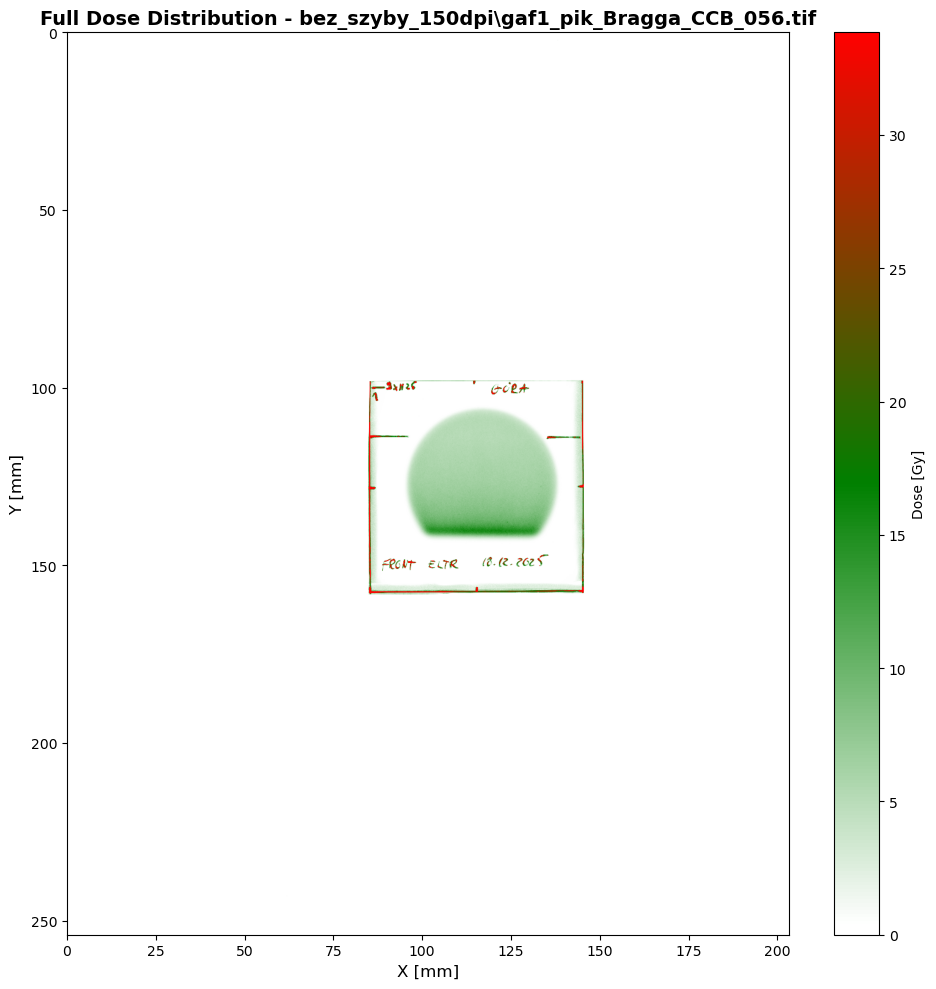

Cropped region: Y[614:854], X[552:826]
Cropped size before rotation: (240, 274)
Cropped size after rotation: (274, 240)


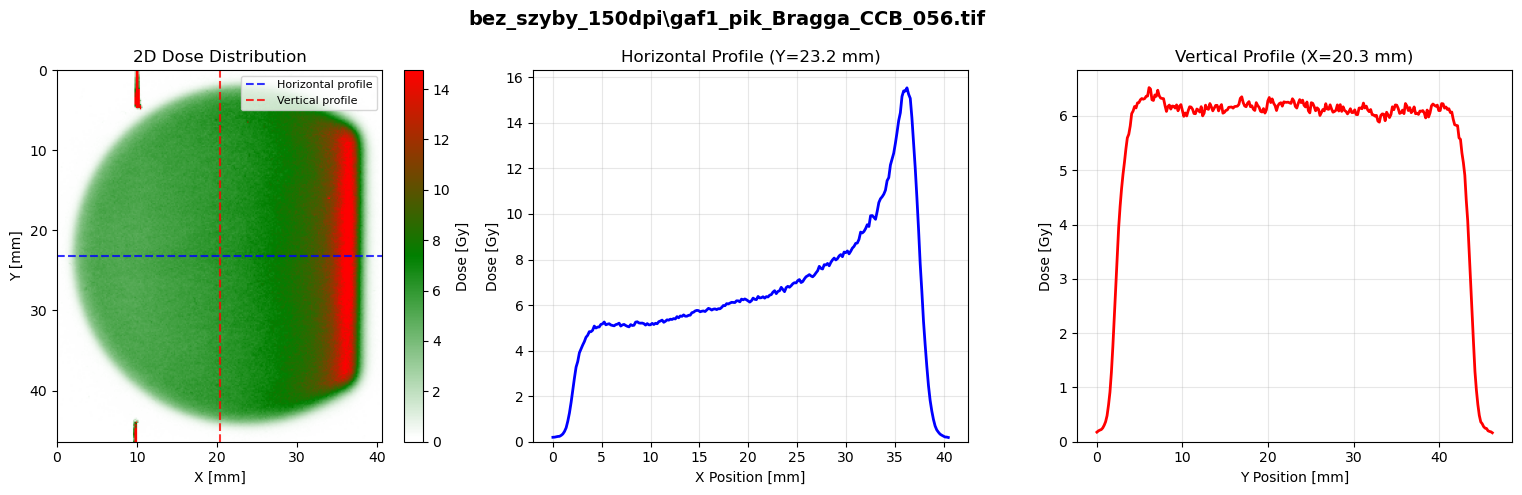

In [6]:
if file_data:
    rel_path = file_data.path.relative_to(DATA_DIR)
    px_to_mm = file_data.px_to_mm
    
    # 1. Plot full dose distribution
    dose_full = file_data.dose_full
    vmax = np.percentile(dose_full[dose_full > 0], 99) if (dose_full > 0).any() else dose_full.max()
    
    fig, ax, im = plot_2d_dose(
        dose_full, 
        px_to_mm=px_to_mm,
        title=f'Full Dose Distribution - {rel_path}',
        vmin=0, 
        vmax=vmax,
        white_threshold_percent=CMAP_WHITE_THRESHOLD_PERCENT,
        figsize=(12, 10)
    )
    plt.show()
    
    # 2. Auto-crop and rotate
    dose_cropped, bbox = auto_crop_dose(
        dose_full,
        px_to_mm=px_to_mm,
        dose_threshold_gy=CROP_DOSE_THRESHOLD_GY,
        smooth_sigma_mm=CROP_SMOOTH_SIGMA_MM,
        min_diameter_mm=CROP_MIN_DIAMETER_MM,
        margin_mm=CROP_MARGIN_MM,
    )
    print(f'Cropped region: Y[{bbox[0]}:{bbox[1]}], X[{bbox[2]}:{bbox[3]}]')
    print(f'Cropped size before rotation: {dose_cropped.shape}')
    
    # Rotate 90 degrees anti-clockwise
    dose_cropped = rotate_dose(dose_cropped, k=1)
    print(f'Cropped size after rotation: {dose_cropped.shape}')
    
    # Plot cropped dose with profiles
    fig = plot_dose_with_profiles(
        dose_cropped,
        px_to_mm=px_to_mm,
        title=f'{rel_path}',
        white_threshold_percent=CMAP_WHITE_THRESHOLD_PERCENT
    )
    plt.show()
    
    # Store cropped data
    file_data.dose_cropped = dose_cropped
    file_data.crop_bbox = bbox

## Summary of All Files

In [7]:
# Create a summary dataframe
summary_data = []

for stem, file_data in processed_data.items():
    dose = file_data.dose_full
    rel_path = file_data.path.relative_to(DATA_DIR)
    summary_data.append({
        'File (relative)': rel_path,
        'Width [px]': file_data.shape[1],
        'Height [px]': file_data.shape[0],
        'Width [mm]': file_data.shape[1] * file_data.px_to_mm,
        'Height [mm]': file_data.shape[0] * file_data.px_to_mm,
        'DPI': file_data.dpi,
        'Min Dose [Gy]': dose.min(),
        'Max Dose [Gy]': dose.max(),
        'Mean Dose [Gy]': dose.mean(),
        'Std Dose [Gy]': dose.std()
    })

df_summary = pd.DataFrame(summary_data)
print('\nSummary of all processed files:')
print(df_summary.to_string(index=False))


Summary of all processed files:
                                File (relative)  Width [px]  Height [px]  Width [mm]  Height [mm]   DPI  Min Dose [Gy]  Max Dose [Gy]  Mean Dose [Gy]  Std Dose [Gy]
   bez_szyby_150dpi\gaf1_pik_Bragga_CCB_056.tif        1200         1500       203.2        254.0 150.0      -1.182017     120.752474       -0.823129       2.122682
szyba1_150dpi\gaf1_pik_Bragga_CCB_SZYBA1057.tif        1200         1500       203.2        254.0 150.0      -1.182017     117.929315       -0.826709       2.118319
 szyba1_72dpi\gaf1_pik_Bragga_CCB_SZYBA1058.tif         576          720       203.2        254.0  72.0      -1.182017      84.234340       -0.851750       1.798758


## Visualize All Files


Visualizing: bez_szyby_150dpi\gaf1_pik_Bragga_CCB_056.tif (DPI: 150.0)



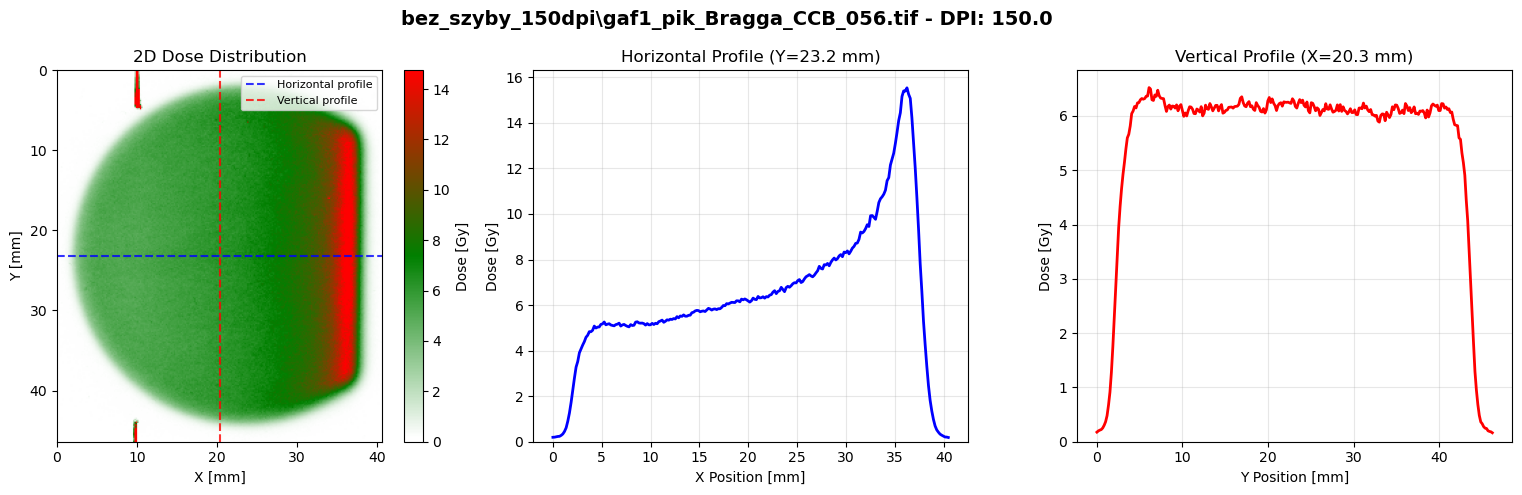


Visualizing: szyba1_150dpi\gaf1_pik_Bragga_CCB_SZYBA1057.tif (DPI: 150.0)



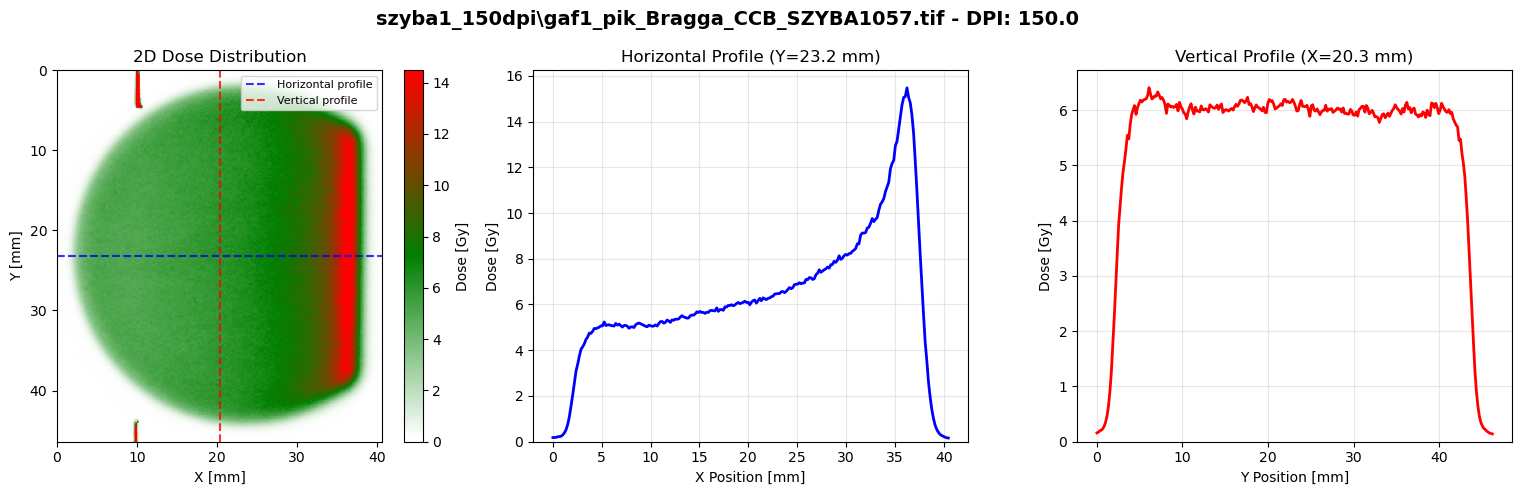


Visualizing: szyba1_72dpi\gaf1_pik_Bragga_CCB_SZYBA1058.tif (DPI: 72.0)



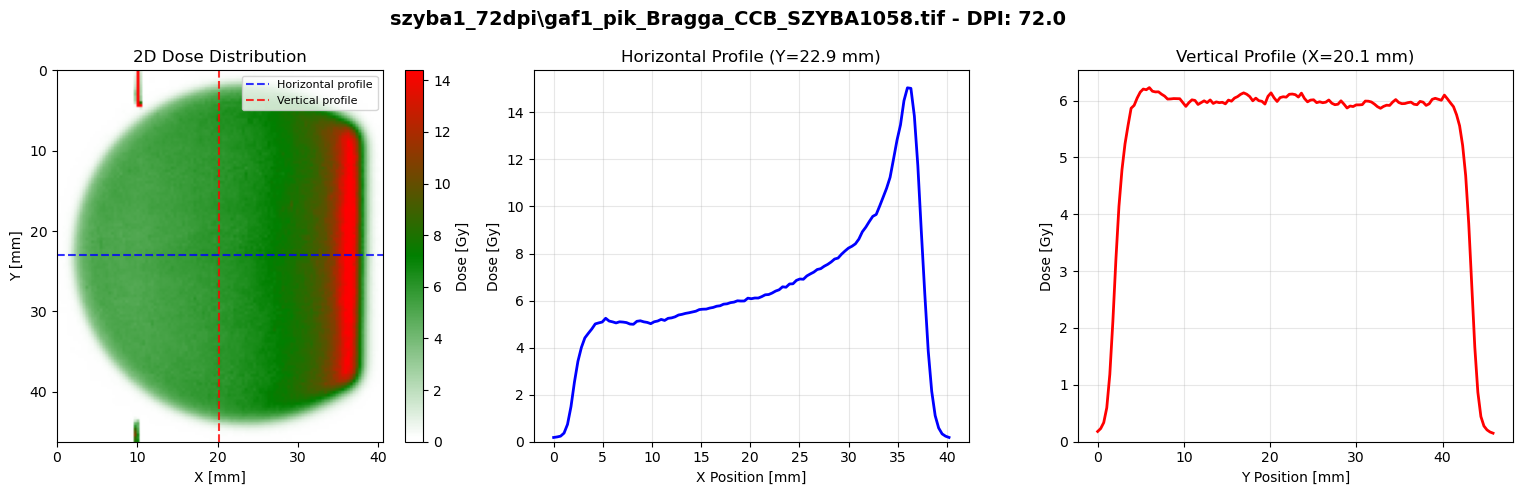

In [8]:
# Loop through all files and create plots
for stem, file_data in processed_data.items():
    rel_path = file_data.path.relative_to(DATA_DIR)
    px_to_mm = file_data.px_to_mm
    
    print(f'\n{"="*60}')
    print(f'Visualizing: {rel_path} (DPI: {file_data.dpi:.1f})')
    print(f'{"="*60}\n')
    
    dose_full = file_data.dose_full
    
    # Auto-crop with per-file px_to_mm
    dose_cropped, bbox = auto_crop_dose(
        dose_full,
        px_to_mm=px_to_mm,
        dose_threshold_gy=CROP_DOSE_THRESHOLD_GY,
        smooth_sigma_mm=CROP_SMOOTH_SIGMA_MM,
        min_diameter_mm=CROP_MIN_DIAMETER_MM,
        margin_mm=CROP_MARGIN_MM,
    )
    
    # Rotate 90 degrees anti-clockwise
    dose_cropped = rotate_dose(dose_cropped, k=1)
    
    # Plot dose with profiles
    fig = plot_dose_with_profiles(
        dose_cropped,
        px_to_mm=px_to_mm,
        title=f'{rel_path} - DPI: {file_data.dpi:.1f}',
        white_threshold_percent=CMAP_WHITE_THRESHOLD_PERCENT
    )
    plt.show()
    
    # Store cropped data
    file_data.dose_cropped = dose_cropped
    file_data.crop_bbox = bbox

## Profile Comparison Across All Files

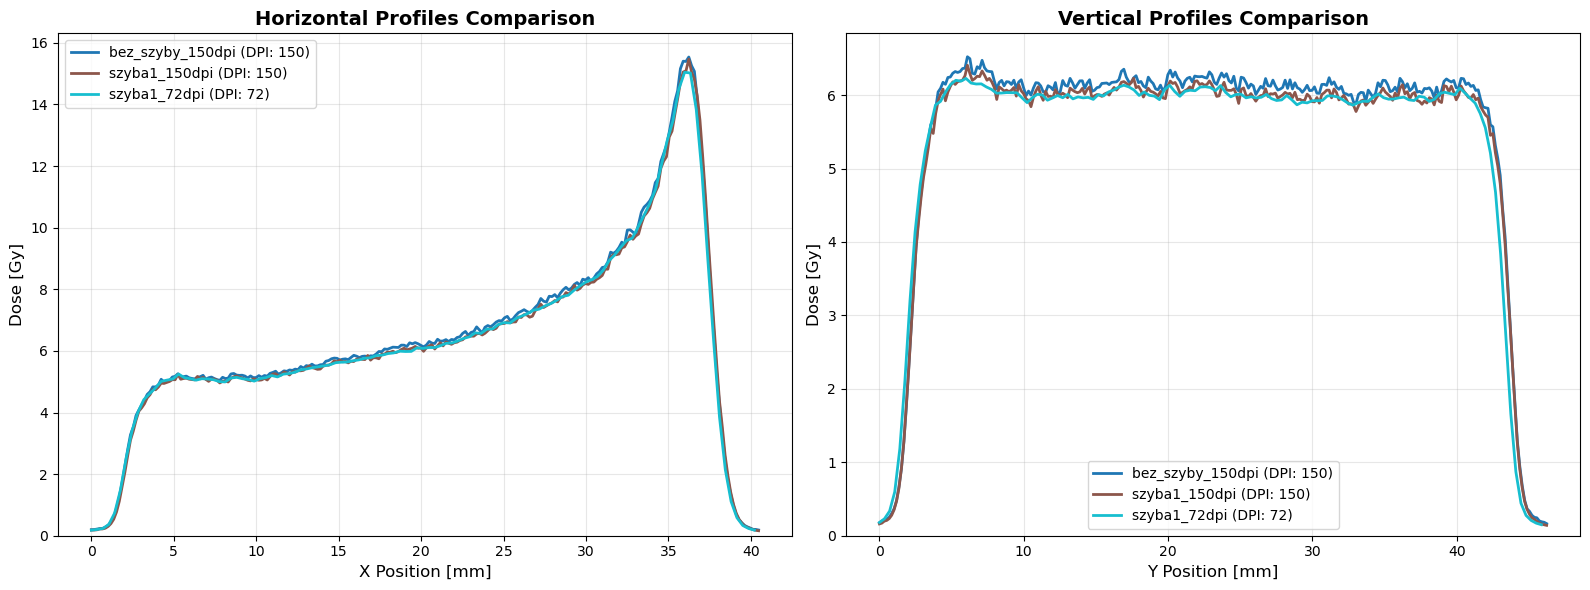

In [9]:
# Compare profiles from all files
fig, (ax_h, ax_v) = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(processed_data)))

for idx, (stem, file_data) in enumerate(processed_data.items()):
    if file_data.dose_cropped is None:
        continue
    
    rel_path = file_data.path.relative_to(DATA_DIR)
    dose_cropped = file_data.dose_cropped
    px_to_mm = file_data.px_to_mm
    height, width = dose_cropped.shape
    
    # Calculate profiles at center
    y_pos = height // 2
    x_pos = width // 2
    hw = 5  # half-width for averaging
    
    # Horizontal profile
    h_profile = dose_cropped[max(0, y_pos-hw):min(height, y_pos+hw), :].mean(axis=0)
    h_x_mm = np.arange(len(h_profile)) * px_to_mm
    ax_h.plot(h_x_mm, h_profile, '-', linewidth=2, color=colors[idx], 
              label=f'{rel_path.parent.name} (DPI: {file_data.dpi:.0f})')
    
    # Vertical profile
    v_profile = dose_cropped[:, max(0, x_pos-hw):min(width, x_pos+hw)].mean(axis=1)
    v_y_mm = np.arange(len(v_profile)) * px_to_mm
    ax_v.plot(v_y_mm, v_profile, '-', linewidth=2, color=colors[idx], 
              label=f'{rel_path.parent.name} (DPI: {file_data.dpi:.0f})')

# Format horizontal profile plot
ax_h.set_xlabel('X Position [mm]', fontsize=12)
ax_h.set_ylabel('Dose [Gy]', fontsize=12)
ax_h.set_title('Horizontal Profiles Comparison', fontsize=14, fontweight='bold')
ax_h.grid(True, alpha=0.3)
ax_h.set_ylim(0, None)
ax_h.legend(loc='best', fontsize=10)

# Format vertical profile plot
ax_v.set_xlabel('Y Position [mm]', fontsize=12)
ax_v.set_ylabel('Dose [Gy]', fontsize=12)
ax_v.set_title('Vertical Profiles Comparison', fontsize=14, fontweight='bold')
ax_v.grid(True, alpha=0.3)
ax_v.set_ylim(0, None)
ax_v.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()